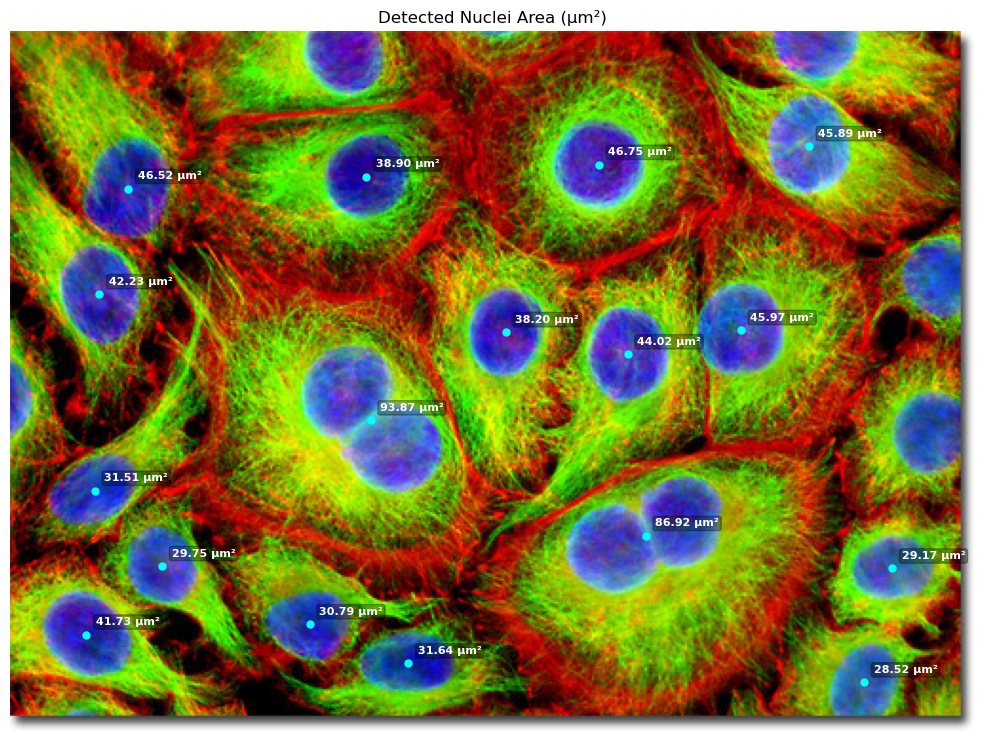

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, filters, color, io
from skimage.segmentation import clear_border
from skimage.morphology import remove_small_objects

# Configuration
image_path = "helalarge3.jpg"  # Replace if needed
microns_per_pixel = 0.16125  # µm per pixel (40× objective lens)
pixel_area_um2 = microns_per_pixel ** 2

# Load image
img = io.imread(image_path)

# Convert to grayscale using blue channel (nuclei)
nuclei_gray = img[:, :, 2]
threshold = filters.threshold_otsu(nuclei_gray)
nuclei_binary = nuclei_gray > threshold

# Clean up binary mask
nuclei_binary = clear_border(nuclei_binary)
nuclei_binary = remove_small_objects(nuclei_binary, 100)

# Label and measure regions
labeled_nuclei = measure.label(nuclei_binary)
props = measure.regionprops(labeled_nuclei)

# Plot original image with annotations
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)

for prop in props:
    y, x = prop.centroid
    area_px = prop.area
    area_um2 = area_px * pixel_area_um2  # convert to µm²

    ax.plot(x, y, 'o', color='cyan', markersize=5)
    ax.text(x + 5, y - 5, f"{area_um2:.2f} µm²", color='white',
            fontsize=8, weight='bold', bbox=dict(facecolor='black', alpha=0.3, boxstyle='round,pad=0.2'))

ax.set_title("Detected Nuclei Area (µm²)")
plt.axis('off')
plt.tight_layout()
plt.show()


